# **Predicción de delitos por series temporales**

Purpose:
- Entrenar y predecir con Prophet (principal), XGBoost y SARIMAX bajo el mismo framing N días y misma grilla H3.

Assumptions:
- Datos diarios por (cell_id, categoria_delito): columnas   ['ds','cell_id','categoria_delito','y','set','cluster_id', ...]
- Etiquetas N-días ya calculadas (ETAPA 2), features ya calculadas (ETAPA 3).
- Para Prophet/SARIMAX por cluster: agregamos y por (cluster_id, categoria, ds).

Outputs:
- Dicts de modelos Prophet/SARIMAX por (cluster_id, categoria)
- Predicciones por cluster (diarias) y su agregación a ventana N
- Downscale a celdas vía pesos históricos sin fuga
- Entrenamiento XGB con DMatrix + early stopping (wrapper agnóstico versión)

# **1. Librerias**

In [31]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import average_precision_score, precision_recall_curve, auc, roc_auc_score, brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping

import os, sys, math, gc, joblib, time
import folium
import folium.plugins as plugins

import warnings
warnings.filterwarnings("ignore")


# **2. CONFIGURACIÓN DEL AMBIENTE**


## 2.1 VARIABLES GLOBALES

In [2]:
# Semilla global para reproducibilidad
SEED = 42

# Le indicamos a Pandas que siempre muestre hasta 50 columnas completas en lugar de cortarlas con “...”.
pd.set_option("display.max_columns", 50)

# Centro aproximado (CDMX por defecto)
CENTER_LAT = 19.4326
CENTER_LON = -99.1332
CRS_METHOD = "aeqd"  # 'aeqd' | 'laea' | 'lcc'

# VENTANA DE DIAS PARA EL PREDICTOR
N_DIAS_TO_PREDICTION = 3
date_col = "ds"
cat_col = "categoria_delito"
y_cnt_col = f"y_cnt_N{N_DIAS_TO_PREDICTION}"

#  Elegir método para discretización espacial
# Opción A (recomendada): H3 r=8
METHOD = "h3"     # "h3" o "geohash"
H3_RES = 8        # ~0.7–1.2 km en CDMX

# Opción B: Geohash-6
GEOHASH_PREC = 6  # ~1 km aprox.

## 2.2 ACCESO A DATOS

In [3]:
# ---- Switch de entorno: "colab" o "local"
RUN_ENV = "local"   # <-- cambia a "local" si no usas Google Colab

# ---- Rutas base
if RUN_ENV.lower() == "colab":
    try:
        from google.colab import drive
        drive.mount("/drive")
    except Exception as e:
        print("Aviso: no se pudo montar Drive automáticamente:", e)
    # Ajusta esta ruta a tu carpeta del proyecto en Drive
    BASE_DIR = "/drive/My Drive/Colab Notebooks/reto-Thales/"
else:
    # Ajusta a tu ruta local del proyecto
    BASE_DIR = "/Users/jorgevalverde/Documents/myEnv/crimen-cdmx/"

os.makedirs(BASE_DIR, exist_ok=True)

print(f"Entorno: {RUN_ENV} | BASE_DIR: {BASE_DIR}")

Entorno: local | BASE_DIR: /Users/jorgevalverde/Documents/myEnv/crimen-cdmx/


In [4]:
DATA_PATH = os.path.join(BASE_DIR, "data", "delitos_cdmx_sample_final_5percent.csv")
SPATIO_TEMPORAL_CELLS_PATH = os.path.join(BASE_DIR, "results/features_temporal_series", "df_cell_temp_serie__N3_D_v1.joblib")
SPATIO_TEMPORAL_FEATS_PATH = os.path.join(BASE_DIR, "results/features_temporal_series", "feat_temp_serie__N3_Dds_v1.joblib")
SPATIO_TEMPORAL_COUNT_SPLIT_PATH = os.path.join(BASE_DIR, "results/features_temporal_series", "counts_D_split_temp_serie__N3_Dds_v1.joblib")

In [5]:
# Vamos utilizar un archivo de funciones propio
#sys.path.insert(0, BASE_DIR) #para acceder desde Colab-Drive
import myUtils as myUtils

Importing plotly failed. Interactive plots will not work.


# **3. LECTURA DE ARTEFACTOS**

In [6]:
# Lectura de las features
df_feats = joblib.load(SPATIO_TEMPORAL_FEATS_PATH)
df_feats

,ds,cell_id,categoria_delito,y,cluster_id,ghost_min_dist_m,ghost_is_near_active,cluster_dist_m,y_cnt_N3,y_bin_N3,set,cal_dow,cal_is_weekend,cal_dow_sin,cal_dow_cos,cal_mon_sin,cal_mon_cos,y_lag1,y_lag2,y_lag3,y_lag7,y_lag14,y_lag28,roll7_mean,roll7_std,...,cluster_roll28_mean_norm,y_lag4,y_lag5,y_lag6,nbr_y_lag1_mean_k1,nbr_y_lag1_p90_k1,nbr_y_lag2_mean_k1,nbr_y_lag2_p90_k1,nbr_y_lag3_mean_k1,nbr_y_lag3_p90_k1,nbr_y_lag4_mean_k1,nbr_y_lag4_p90_k1,nbr_y_lag5_mean_k1,nbr_y_lag5_p90_k1,nbr_y_lag6_mean_k1,nbr_y_lag6_p90_k1,nbr_y_lag7_mean_k1,nbr_y_lag7_p90_k1,prior_mean_365d,prior_var_365d,prior_sum_365d,prior_mean_730d,prior_var_730d,prior_sum_730d,eb_rate_365d
0,2016-01-01,8849864921fffff,delito de bajo impacto,0.0,8.0,0.0,True,NaN,NaN,0,<NA>,4,0,-0.433884,-0.900969,0.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-02,8849864921fffff,delito de bajo impacto,0.0,8.0,0.0,True,NaN,NaN,0,<NA>,5,1,-0.974928,-0.222521,0.0,1.000000,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,0.023256,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.00000,NaN,0.0,0.002732
2,2016-01-03,8849864921fffff,delito de bajo impacto,0.0,8.0,0.0,True,NaN,0.0,0,train,6,1,-0.781831,0.623490,0.0,1.000000,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,...,0.017442,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.00000,0.00000,0.0,0.002732
3,2016-01-04,8849864921fffff,delito de bajo impacto,0.0,8.0,0.0,True,NaN,0.0,0,train,0,0,0.000000,1.000000,0.0,1.000000,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,...,0.027132,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.00000,0.00000,0.0,0.002732
4,2016-01-05,8849864921fffff,delito de bajo impacto,0.0,8.0,0.0,True,NaN,0.0,0,train,1,0,0.781831,0.623490,0.0,1.000000,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,...,0.031977,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.00000,0.00000,0.0,0.002732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15276487,2024-12-06,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0,19.0,0.0,True,1468.944967,0.0,0,test,4,0,-0.433884,-0.900969,-0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.029464,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00137,0.00137,1.0,0.002732
15276488,2024-12-07,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0,19.0,0.0,True,1468.944967,0.0,0,test,5,1,-0.974928,-0.222521,-0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.027679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00137,0.00137,1.0,0.002732
15276489,2024-12-08,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0,19.0,0.0,True,1468.944967,0.0,0,test,6,1,-0.781831,0.623490,-0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.028571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00137,0.00137,1.0,0.002732
15276490,2024-12-09,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0,19.0,0.0,True,1468.944967,NaN,0,<NA>,0,0,0.000000,1.000000,-0.5,0.866025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.025893,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00137,0.00137,1.0,0.002732


In [7]:
# Labels de conteo en test
labels_cnt_test = df_feats.loc[df_feats["set"]=="test", [date_col,"cell_id",cat_col,y_cnt_col]].copy()
labels_cnt_test

,ds,cell_id,categoria_delito,y_cnt_N3
2557,2023-01-01,8849864921fffff,delito de bajo impacto,0.0
2558,2023-01-02,8849864921fffff,delito de bajo impacto,0.0
2559,2023-01-03,8849864921fffff,delito de bajo impacto,0.0
2560,2023-01-04,8849864921fffff,delito de bajo impacto,0.0
2561,2023-01-05,8849864921fffff,delito de bajo impacto,0.0
...,...,...,...,...
15276485,2024-12-04,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0
15276486,2024-12-05,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0
15276487,2024-12-06,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0
15276488,2024-12-07,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0


In [8]:
counts_D_split = joblib.load(SPATIO_TEMPORAL_COUNT_SPLIT_PATH)
counts_D_split

,ds,cell_id,categoria_delito,y,cluster_id,ghost_min_dist_m,ghost_is_near_active,cluster_dist_m,y_cnt_N3,y_bin_N3,set
0,2016-01-01,8849864921fffff,delito de bajo impacto,0.0,8.0,0.0,True,NaN,NaN,0,<NA>
1,2016-01-02,8849864921fffff,delito de bajo impacto,0.0,8.0,0.0,True,NaN,NaN,0,<NA>
2,2016-01-03,8849864921fffff,delito de bajo impacto,0.0,8.0,0.0,True,NaN,0.0,0,train
3,2016-01-04,8849864921fffff,delito de bajo impacto,0.0,8.0,0.0,True,NaN,0.0,0,train
4,2016-01-05,8849864921fffff,delito de bajo impacto,0.0,8.0,0.0,True,NaN,0.0,0,train
...,...,...,...,...,...,...,...,...,...,...,...
15276487,2024-12-06,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0,19.0,0.0,True,1468.944967,0.0,0,test
15276488,2024-12-07,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0,19.0,0.0,True,1468.944967,0.0,0,test
15276489,2024-12-08,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0,19.0,0.0,True,1468.944967,0.0,0,test
15276490,2024-12-09,884995bb6dfffff,robo de vehiculo con y sin violencia,0.0,19.0,0.0,True,1468.944967,NaN,0,<NA>


In [9]:
df_cells = joblib.load(SPATIO_TEMPORAL_CELLS_PATH)
df_cells

,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,competencia,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud,categoria_delito,cell_id,fecha_evento
0,2016,Mayo,2016-10-05,00:00:00,2016,Abril,2016-03-04,12:28:00,AMENAZAS,<NA>,INVESTIGACIÓN EN COYOACÁN,COY-1,UI-1CD,CULHUACÁN CTM SECCIÓN V,Culhuacan Ctm Seccion I,COYOACAN,<NA>,CDMX,19.33182,-99.11862,delito de bajo impacto,88499585e1fffff,2016-03-04
1,2016,Mayo,NaT,00:00:00,2016,Mayo,NaT,15:10:00,LESIONES CULPOSAS POR TRANSITO VEHICULAR EN CO...,<NA>,INVESTIGACIÓN EN CUAUHTEMOC,CUH-2,UI-3CD,DOCTORES,Doctores,CUAUHTEMOC,<NA>,CDMX,19.4248,-99.14254,delito de bajo impacto,884995b84dfffff,NaT
2,2016,Julio,2016-07-07,00:00:00,2016,Mayo,NaT,02:00:00,ROBO DE OBJETOS,<NA>,INVESTIGACIÓN EN CUAUHTEMOC,CUH-2,UI-2SD,SANTA MARIA LA RIBERA,Santa Maria La Ribera,CUAUHTEMOC,<NA>,CDMX,19.44337,-99.15801,delito de bajo impacto,884995b85dfffff,2016-07-07
3,2016,Enero,2016-04-01,00:00:00,2016,Enero,2016-04-01,15:30:00,PERDIDA DE LA VIDA POR OTRAS CAUSAS,<NA>,INVESTIGACIÓN EN CUAUHTEMOC,CUH-8,UI-3CD,ESPERANZA,Esperanza,CUAUHTEMOC,<NA>,CDMX,19.42177,-99.12674,hecho no delictivo,884995bb11fffff,2016-04-01
4,2016,Febrero,2016-08-02,00:00:00,2016,Febrero,2016-01-02,14:00:00,VIOLENCIA FAMILIAR,<NA>,INVESTIGACIÓN EN XOCHIMILCO,XO-2,UI-2SD,LA JOYA,<NA>,XOCHIMILCO,<NA>,CDMX,19.231226,-99.095951,delito de bajo impacto,88499580dbfffff,2016-01-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10256962,2025,Enero,NaT,16:25:45:00,2025,Enero,NaT,14:00:00:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,UAT-TLP-5,UI-1SD,PEDREGAL DE AMINCO,Pueblo San Francisco Tlalnepantla,TLALPAN,<NA>,CDMX,19.201846,-99.131102,delito de bajo impacto,88499595a7fffff,NaT
10256963,2025,Enero,NaT,17:56:48:00,2025,Enero,NaT,14:58:00:00,VIOLENCIA FAMILIAR,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,TLP-3,UI-1CD,SAN MIGUEL TOPILEJO,Pueblo San Miguel Topilejo,TLALPAN,<NA>,CDMX,19.191853,-99.141353,delito de bajo impacto,88499595abfffff,NaT
10256964,2025,Enero,NaT,02:13:04:00,2024,Diciembre,NaT,06:00:00:00,ROBO A PASAJERO A BORDO DE METRO SIN VIOLENCIA,FUERO COMUN,AGENCIA DE DENUNCIA DIGITAL,CEN-A,UI-1SD,SANTA MARIA NONOALCO,Santa Maria Nonoalco,BENITO JUAREZ,<NA>,CDMX,19.384536,-99.186575,OTRAS,884995ba5dfffff,NaT
10256965,2025,Enero,NaT,23:51:01:00,2022,Enero,NaT,12:00:00:00,DESPOJO,FUERO COMUN,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN COYOACÁN,COY-1,UI-2CD,ROMERO DE TERREROS,Romero De Terreros,COYOACAN,<NA>,CDMX,19.343661,-99.168056,delito de bajo impacto,88499584adfffff,NaT


In [10]:
test_dates = pd.to_datetime(counts_D_split.loc[counts_D_split["set"]=="test", date_col].unique())
test_dates = pd.DatetimeIndex(np.sort(test_dates))
print("Fechas de test:", test_dates.min(), "→", test_dates.max())

Fechas de test: 2023-01-01 00:00:00 → 2024-12-08 00:00:00


# **4.PREDICCIÓN**

## 4.1 PROPHET

In [11]:
# Agregar a nivel cluster-categoría
df_clu = myUtils.aggregate_daily_by_cluster_category(
    counts_D_split, date_col=date_col, y_col="y",
    cluster_col="cluster_id", cat_col="categoria_delito"
)
df_clu

,cluster_id,categoria_delito,ds,y_cluster
199287,0.0,OTRAS,2016-01-01,0.0
199288,0.0,OTRAS,2016-01-02,0.0
199289,0.0,OTRAS,2016-01-03,1.0
199290,0.0,OTRAS,2016-01-04,0.0
199291,0.0,OTRAS,2016-01-05,0.0
...,...,...,...,...
238486,19.0,robo de vehiculo con y sin violencia,2024-12-06,0.0
238487,19.0,robo de vehiculo con y sin violencia,2024-12-07,0.0
238488,19.0,robo de vehiculo con y sin violencia,2024-12-08,0.0
238489,19.0,robo de vehiculo con y sin violencia,2024-12-09,0.0


In [12]:
# Entrenar Prophet por (cluster,cat) sólo en TRAIN
train_end = counts_D_split.loc[counts_D_split["set"]=="train", date_col].max()
models_prophet = myUtils.fit_prophet_by_cluster_category(
    df_cluster_daily=df_clu,
    date_col=date_col, y_col="y_cluster",
    cluster_col="cluster_id", cat_col="categoria_delito",
    train_start="2016-01-01",
    train_end=str(train_end.date()),
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    changepoint_prior_scale=0.1,
    holidays_df=None  # opcional
)
print(f"Modelos Prophet entrenados: {len(models_prophet)}")

10:58:11 - cmdstanpy - INFO - Chain [1] start processing
10:58:12 - cmdstanpy - INFO - Chain [1] done processing
10:58:12 - cmdstanpy - INFO - Chain [1] start processing
10:58:12 - cmdstanpy - INFO - Chain [1] done processing
10:58:12 - cmdstanpy - INFO - Chain [1] start processing
10:58:12 - cmdstanpy - INFO - Chain [1] done processing
10:58:12 - cmdstanpy - INFO - Chain [1] start processing
10:58:12 - cmdstanpy - INFO - Chain [1] done processing
10:58:12 - cmdstanpy - INFO - Chain [1] start processing
10:58:12 - cmdstanpy - INFO - Chain [1] done processing
10:58:12 - cmdstanpy - INFO - Chain [1] start processing
10:58:12 - cmdstanpy - INFO - Chain [1] done processing
10:58:12 - cmdstanpy - INFO - Chain [1] start processing
10:58:12 - cmdstanpy - INFO - Chain [1] done processing
10:58:12 - cmdstanpy - INFO - Chain [1] start processing
10:58:13 - cmdstanpy - INFO - Chain [1] done processing
10:58:13 - cmdstanpy - INFO - Chain [1] start processing
10:58:13 - cmdstanpy - INFO - Chain [1]

Modelos Prophet entrenados: 120


In [13]:
# Predicción ventana N por cluster/categoría para todas las fechas de test
pred_prophet_clusterN = myUtils.prophet_predict_cluster_windowN(
    models=models_prophet,
    horizon_dates=test_dates,
    N=N_DIAS_TO_PREDICTION
)
pred_prophet_clusterN

,ds,yhat_N,cluster_id,categoria_delito
0,2023-01-01,0.137995,0,OTRAS
1,2023-01-02,0.144420,0,OTRAS
2,2023-01-03,0.155672,0,OTRAS
3,2023-01-04,0.136080,0,OTRAS
4,2023-01-05,0.143135,0,OTRAS
...,...,...,...,...
84955,2024-12-04,0.103061,19,robo de vehiculo con y sin violencia
84956,2024-12-05,0.120169,19,robo de vehiculo con y sin violencia
84957,2024-12-06,0.086434,19,robo de vehiculo con y sin violencia
84958,2024-12-07,0.111930,19,robo de vehiculo con y sin violencia


In [14]:
# Downscale a celdas usando pesos del FINAL de train (28 días previos)
weights = myUtils.make_downscale_weights_at_train_end(
    counts_D_split,
    date_col=date_col, y_col="y",
    cluster_col="cluster_id", cell_col="cell_id", cat_col="categoria_delito",
    set_col="set", train_set_value="train",
    ref_window_days=28
)
pred_prophet_cellN = myUtils.downscale_cluster_predictions_to_cells(
    pred_clusterN=pred_prophet_clusterN,
    weights_df=weights
)
pred_prophet_cellN


,ds,cell_id,categoria_delito,yhat_N_cell
0,2023-01-01,8849958533fffff,OTRAS,0.0
1,2023-01-01,8849958581fffff,OTRAS,0.0
2,2023-01-01,8849958585fffff,OTRAS,0.0
3,2023-01-01,8849958587fffff,OTRAS,0.0
4,2023-01-01,8849958589fffff,OTRAS,0.0
...,...,...,...,...
3310603,2024-12-08,884995bb63fffff,robo de vehiculo con y sin violencia,0.0
3310604,2024-12-08,884995bb65fffff,robo de vehiculo con y sin violencia,0.0
3310605,2024-12-08,884995bb69fffff,robo de vehiculo con y sin violencia,0.0
3310606,2024-12-08,884995bb6bfffff,robo de vehiculo con y sin violencia,0.0


In [15]:
# Construir ranking Top-k por categoría y fecha (usando yhat_N_cell como 'score')
k = 5  # ajusta según lo que observemos 
scores_prophet = pred_prophet_cellN.rename(columns={"yhat_N_cell":"score"})
topk_prophet = myUtils.rank_hotspots_topk_from_scores(
    scores_df=scores_prophet, k=k, method="h3", date_col="ds"
)
topk_prophet


,cell_id,categoria_delito,score,lon,lat,ds
0,884995b849fffff,delito de bajo impacto,1.707946,-99.149733,19.424988,2023-01-01
1,8849958ecdfffff,delito de bajo impacto,0.987774,-99.067024,19.322605,2023-01-01
2,88499584b5fffff,delito de bajo impacto,0.977089,-99.188260,19.367740,2023-01-01
3,884995b843fffff,delito de bajo impacto,0.948859,-99.150812,19.440430,2023-01-01
4,884995b84dfffff,delito de bajo impacto,0.948859,-99.140328,19.425699,2023-01-01
...,...,...,...,...,...,...
22447,8849958f59fffff,hecho no delictivo,0.056573,-98.993933,19.289329,2024-12-08
22448,884995b139fffff,hecho no delictivo,0.055117,-99.238543,19.410489,2024-12-08
22449,8849958485fffff,robo a negocio con violencia,0.047830,-99.191335,19.344224,2024-12-08
22450,8849958689fffff,robo a negocio con violencia,0.020407,-99.233982,19.278892,2024-12-08


In [16]:
# Evaluación espacial Hit@k@R para una fecha o rango
#    Preparamos 'truth' en test: incidentes reales por fecha
df_truth_test = counts_D_split[counts_D_split["set"]=="test"].copy()
# truth en puntos: toma incidentes originales del periodo test.
# Si no, se puede muestrear por centroids por cada evento diario; aquí mostramos evaluación por fecha con tus funciones base.

# Ejemplo: evaluar un día específico
eval_day = test_dates.min()

truth_day_pts = df_cells.loc[df_cells["fecha_evento"] == eval_day, ["latitud","longitud","categoria_delito"]].copy()
topk_day = topk_prophet.loc[topk_prophet["ds"] == eval_day].copy()  # topk_prophet ya trae 'lat' y 'lon'

hitk_day = myUtils.hit_at_k_radius(
    topk_df=topk_day,            # mantiene 'lat','lon'
    truth_df=truth_day_pts,      # tiene 'latitud','longitud'
    cat_col="categoria_delito",
    radius_m=500.0
)

hitk_day


,categoria_delito,n_events,n_hits,hit_rate
0,OTRAS,4,0,0.00
1,delito de bajo impacto,80,4,0.05
2,robo a negocio con violencia,1,0,0.00


## 4.2  XGBoost

In [17]:
# Columnas de features numéricas 
label_bin = f"y_bin_N{N_DIAS_TO_PREDICTION}"
exclude = {date_col, "cell_id", "categoria_delito", "set", label_bin, f"y_cnt_N{N_DIAS_TO_PREDICTION }"}
X_cols = [c for c in df_feats.columns if c not in exclude and pd.api.types.is_numeric_dtype(df_feats[c])]

# 2) Entrenar clasificador
booster, best_iter, best_score = myUtils.fit_xgb_classifier_dmatrix(
    df_feats=df_feats,
    feature_cols=X_cols,
    label_col=label_bin,
    set_col="set",
    train_set_value="train",
    valid_frac=0.2,
    shuffle=False,
    params={"eval_metric":"logloss"},
    num_boost_round=1000,
    early_stopping_rounds=30
)
print("Best iter:", best_iter, "| best_score:", best_score)


Best iter: 78 | best_score: 0.36174905909995


In [18]:
# Predicción en test y ranking top-k (por fecha si lo deseas)
test_mask = (df_feats["set"]=="test")
proba_test = myUtils.predict_xgb_classifier(booster, df_feats.loc[test_mask], X_cols)
scores_xgb = pd.DataFrame({
    "ds": df_feats.loc[test_mask, date_col].values,
    "cell_id": df_feats.loc[test_mask, "cell_id"].values,
    "categoria_delito": df_feats.loc[test_mask, "categoria_delito"].values,
    "score": proba_test.values
})

topk_xgb = myUtils.rank_hotspots_topk_from_scores(
    scores_df=scores_xgb, k=5, method="h3", date_col="ds"
)
topk_xgb.head()


,cell_id,categoria_delito,score,lon,lat,ds
0,884995b863fffff,delito de bajo impacto,0.999316,-99.127838,19.449926,2023-01-01
1,884995b8c3fffff,delito de bajo impacto,0.999301,-99.187528,19.491996,2023-01-01
2,884995bb09fffff,delito de bajo impacto,0.999296,-99.109969,19.396949,2023-01-01
3,884995bb09fffff,delito de bajo impacto,0.999296,-99.109969,19.396949,2023-01-01
4,884995ba0bfffff,delito de bajo impacto,0.999265,-99.181025,19.399334,2023-01-01


In [19]:
# 3) Predicción en test y ranking top-k (por fecha si lo deseas)
test_mask = (df_feats["set"]=="test")
proba_test = myUtils.predict_xgb_classifier(booster, df_feats.loc[test_mask], X_cols)
scores_xgb = pd.DataFrame({
    "ds": df_feats.loc[test_mask, date_col].values,
    "cell_id": df_feats.loc[test_mask, "cell_id"].values,
    "categoria_delito": df_feats.loc[test_mask, "categoria_delito"].values,
    "score": proba_test.values
})

topk_xgb = myUtils.rank_hotspots_topk_from_scores(
    scores_df=scores_xgb, k=5, method="h3", date_col="ds"
)
topk_xgb.head()


,cell_id,categoria_delito,score,lon,lat,ds
0,884995b863fffff,delito de bajo impacto,0.999316,-99.127838,19.449926,2023-01-01
1,884995b8c3fffff,delito de bajo impacto,0.999301,-99.187528,19.491996,2023-01-01
2,884995bb09fffff,delito de bajo impacto,0.999296,-99.109969,19.396949,2023-01-01
3,884995bb09fffff,delito de bajo impacto,0.999296,-99.109969,19.396949,2023-01-01
4,884995ba0bfffff,delito de bajo impacto,0.999265,-99.181025,19.399334,2023-01-01


In [20]:
# XGBoost prediccion completa
prior_window = 28  # o 4 si estás en semanas

prior_df = (
    counts_D_split.sort_values([cat_col, "cell_id", date_col])
    .groupby([cat_col, "cell_id"], group_keys=True)
    .apply(lambda g: g.assign(
        lambda_prior=g["y"].shift(1).rolling(window=prior_window, min_periods=7).mean()
    ))
    .reset_index(drop=True)
)

prior_test = prior_df.loc[prior_df["set"]=="test", [date_col, "cell_id", cat_col, "lambda_prior"]].copy()


# topk_xgb contiene columnas: [cell_id, categoria_delito, score, lon, lat, ds]
df_xgb_cnt = topk_xgb.merge(
    prior_test,
    left_on=["ds", "cell_id", "categoria_delito"],
    right_on=[date_col, "cell_id", cat_col],
    how="left"
)

# si no hay lambda_prior (por celdas nuevas), asumimos 0
df_xgb_cnt["lambda_prior"] = df_xgb_cnt["lambda_prior"].fillna(0.0)

# estimación de conteo esperado
df_xgb_cnt["yhat_cnt_xgb"] = df_xgb_cnt["score"].astype(float) * df_xgb_cnt["lambda_prior"].astype(float)

# conservar columnas clave
df_xgb_cnt = df_xgb_cnt[[date_col, "cell_id", cat_col, "yhat_cnt_xgb", "score", "lambda_prior"]]


df_xgb_cnt.head(10)

,ds,cell_id,categoria_delito,yhat_cnt_xgb,score,lambda_prior
0,2023-01-01,884995b863fffff,delito de bajo impacto,0.035690,0.999316,0.035714
1,2023-01-01,884995b8c3fffff,delito de bajo impacto,0.035689,0.999301,0.035714
2,2023-01-01,884995bb09fffff,delito de bajo impacto,0.035689,0.999296,0.035714
3,2023-01-01,884995bb09fffff,delito de bajo impacto,0.035689,0.999296,0.035714
4,2023-01-01,884995ba0bfffff,delito de bajo impacto,0.071376,0.999265,0.071429
5,2023-01-01,884995b9c5fffff,delito de bajo impacto,0.035688,0.999265,0.035714
6,2023-01-01,8849958cd1fffff,OTRAS,0.000000,0.998974,0.000000
7,2023-01-01,8849958c55fffff,robo a negocio con violencia,0.000000,0.998724,0.000000
8,2023-01-01,8849958eb1fffff,OTRAS,0.000000,0.998660,0.000000
9,2023-01-01,88499595a3fffff,OTRAS,0.000000,0.998637,0.000000


## 4.3 SARIMAX

In [21]:
# Entrenar SARIMAX por cluster/categoría 
models_sarimax = myUtils.fit_sarimax_by_cluster_category(
    df_cluster_daily=df_clu,
    date_col=date_col, y_col="y_cluster",
    cluster_col="cluster_id", cat_col="categoria_delito",
    order=(1,0,1), seasonal_order=(1,0,1,7),
    enforce_stationarity=False, enforce_invertibility=False
)
print("Modelos SARIMAX:", len(models_sarimax))


/Users/jorgevalverde/Documents/myEnv/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/jorgevalverde/Documents/myEnv/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Modelos SARIMAX: 120


In [22]:
# Predicciones ventana N y downscale
pred_sarimax_clusterN = myUtils.sarimax_predict_cluster_windowN(
    models=models_sarimax,
    horizon_dates=test_dates,
    N=N_DIAS_TO_PREDICTION
)
pred_sarimax_cellN = myUtils.downscale_cluster_predictions_to_cells(
    pred_clusterN=pred_sarimax_clusterN,
    weights_df=weights
)
scores_sarimax = pred_sarimax_cellN.rename(columns={"yhat_N_cell":"score"})
topk_sarimax = myUtils.rank_hotspots_topk_from_scores(
    scores_df=scores_sarimax, k=5, method="h3", date_col="ds"
)
topk_sarimax.head()

,cell_id,categoria_delito,score,lon,lat,ds
0,8849958195fffff,OTRAS,0.107735,-99.006425,19.265127,2023-01-01
1,8849959405fffff,OTRAS,0.090336,-99.176185,19.128172,2023-01-01
2,88499582a9fffff,OTRAS,0.090336,-99.072029,19.190386,2023-01-01
3,8849958685fffff,robo a transeunte en via publica con y sin vio...,0.058634,-99.220431,19.287687,2023-01-01
4,88499586c5fffff,robo a transeunte en via publica con y sin vio...,0.058634,-99.223498,19.264175,2023-01-01


## 4.4 SCORE COMBINADO

In [23]:
cat_col = "categoria_delito"

# Escalar Prophet por (ds, categoria) a [0,1]
def _minmax_group(df, val_col):
    v = df[val_col].values.astype(float)
    v_min, v_max = np.nanmin(v), np.nanmax(v)
    if not np.isfinite(v_min) or not np.isfinite(v_max):
        return np.zeros_like(v, dtype=float)
    if np.isclose(v_max, v_min):
        return np.zeros_like(v, dtype=float)
    return (v - v_min) / (v_max - v_min)

prophet_scaled = (
    pred_prophet_cellN
    .copy()
    .dropna(subset=["yhat_N_cell"])
    .groupby([date_col, cat_col], group_keys=False)
    .apply(lambda g: g.assign(scaled_yhat_prophet=_minmax_group(g, "yhat_N_cell")))
)

# Unir con las probas de XGB
comb_base = scores_xgb.merge(
    prophet_scaled[[date_col, "cell_id", cat_col, "scaled_yhat_prophet"]],
    on=[date_col, "cell_id", cat_col],
    how="left"
)

#  Score combinado: 0.6 de XGboos * 0.4 de Prophet
comb_base["scaled_yhat_prophet"] = comb_base["scaled_yhat_prophet"].fillna(0.0)
comb_base["score_comb"] = 0.6 * comb_base["score"].astype(float) + 0.4 * comb_base["scaled_yhat_prophet"].astype(float)

scores_comb = comb_base[[date_col, "cell_id", cat_col, "score_comb"]].rename(columns={"score_comb":"score"})
print("scores_comb listo:", scores_comb.shape)
scores_comb.head()

scores_comb listo: (3310608, 4)


,ds,cell_id,categoria_delito,score
0,2023-01-01,8849864921fffff,delito de bajo impacto,0.107756
1,2023-01-02,8849864921fffff,delito de bajo impacto,0.353349
2,2023-01-03,8849864921fffff,delito de bajo impacto,0.360095
3,2023-01-04,8849864921fffff,delito de bajo impacto,0.350369
4,2023-01-05,8849864921fffff,delito de bajo impacto,0.357821


## 4.5 Métricas de clasificación

Alineamos labels (binaria y_bin_N{N}) desde df_feats (set=='test') y calculamos métricas globales y por categoría para:

- scores_xgb (XGB)

- scores_prophet (Prophet escalado)

- scores_comb (combinado)

In [24]:
label_col = f"y_bin_N{N_DIAS_TO_PREDICTION}"

# Labels de test
labels_test = (
    df_feats.loc[df_feats["set"]=="test", [date_col, "cell_id", cat_col, label_col]]
      .dropna(subset=[label_col])
      .copy()
)
labels_test[label_col] = labels_test[label_col].astype(int)

# Evaluar XGBoost
glob_xgb, bycat_xgb, eval_xgb = myUtils.eval_classification_temporal_series(
    scores_df=scores_xgb,
    labels_df=labels_test,
    name="xgb",
    date_col=date_col,
    cat_col=cat_col,
    label_col=label_col
)

# Evaluar Prophet
glob_prop, bycat_prop, eval_prop = myUtils.eval_classification_temporal_series(
    scores_df=prophet_scaled[[date_col,"cell_id",cat_col,"scaled_yhat_prophet"]].rename(columns={"scaled_yhat_prophet":"score"}),
    labels_df=labels_test,
    name="prophet",
    date_col=date_col,
    cat_col=cat_col,
    label_col=label_col
)

# Evaluar score combinado
glob_comb, bycat_comb, eval_comb = myUtils.eval_classification_temporal_series(
    scores_df=scores_comb,
    labels_df=labels_test,
    name="comb",
    date_col=date_col,
    cat_col=cat_col,
    label_col=label_col
)

print("XGB  ->", glob_xgb)
print("PRO  ->", glob_prop)
print("COMB ->", glob_comb)

XGB  -> {'pr_auc': np.float64(0.588878248411458), 'roc_auc': np.float64(0.9531057532875304), 'brier': np.float64(0.09150628531179508)}
PRO  -> {'pr_auc': np.float64(0.01623876692954285), 'roc_auc': np.float64(0.5207329933608846), 'brier': np.float64(0.047644282684445635)}
COMB -> {'pr_auc': np.float64(0.3126185518846798), 'roc_auc': np.float64(0.9423489235774386), 'brier': np.float64(0.05294725168037314)}


- XGBoost domina completamente la clasificación espacial.
- El ensamble (COMB) conserva su capacidad predictiva con un perfil más “suavizado” (útil para pronósticos operativos).
- Prophet por sí solo no capta la distribución espacial, aunque puede aportar tendencia temporal.


| Modelo        | PR-AUC    | ROC-AUC   | Brier ↓    | Interpretación                                                                                                                                   |
| ------------- | --------- | --------- | ---------- | ------------------------------------------------------------------------------------------------------------------------------------------------ |
| **XGB**       | **0.589** | **0.953** | 0.0915     | Excelente discriminación (ROC), buena calibración; detecta correctamente la mayoría de eventos y distingue bien entre zonas activas e inactivas. |
| **Prophet**   | 0.016     | 0.521     | **0.0476** | Casi aleatorio (ROC ≈ 0.5), sin capacidad espacial; el buen Brier se debe a la **subpredicción constante** (predice todo cerca de 0).            |
| **Combinado** | 0.313     | 0.942     | 0.0529     | Intermedio: mantiene la estructura espacial del XGB pero suaviza su variabilidad. El Brier mejora, indicando mejor calibración probabilística.   |


In [25]:
print("Desempenho de XGBoost")
display(bycat_xgb.head(10))
print("Desempenho de Prophet")
display(bycat_prop.head(10))
print("Desempenho del Modelo Combinado (0.6 · XGB + 0.4 · Prophet)")
display(bycat_comb.head(10))

Desempenho de XGBoost


,categoria_delito,pr_auc,roc_auc,brier,n
1,delito de bajo impacto,0.611958,0.907044,0.291010,764640
4,robo a transeunte en via publica con y sin vio...,0.365572,0.861710,0.038916,530292
0,OTRAS,0.361018,0.849019,0.033286,537372
5,robo de vehiculo con y sin violencia,0.348770,0.842488,0.030791,586224
2,hecho no delictivo,0.345992,0.850313,0.026786,530292
3,robo a negocio con violencia,0.345808,0.820515,0.026659,361788


Desempenho de Prophet


,categoria_delito,pr_auc,roc_auc,brier,n
1,delito de bajo impacto,0.096763,0.628433,0.060636,764640
4,robo a transeunte en via publica con y sin vio...,0.004884,0.587322,0.015673,530292
0,OTRAS,0.003865,0.546066,0.034838,537372
5,robo de vehiculo con y sin violencia,0.003030,0.557521,0.062535,586224
2,hecho no delictivo,0.002947,0.637034,0.028700,530292
3,robo a negocio con violencia,0.001355,0.494843,0.089710,361788


Desempenho del Modelo Combinado (0.6 · XGB + 0.4 · Prophet)


,categoria_delito,pr_auc,roc_auc,brier,n
1,delito de bajo impacto,0.327989,0.886779,0.134148,764640
3,robo a negocio con violencia,0.311397,0.760121,0.038557,361788
5,robo de vehiculo con y sin violencia,0.297413,0.810356,0.035298,586224
2,hecho no delictivo,0.185758,0.842358,0.022335,530292
4,robo a transeunte en via publica con y sin vio...,0.155583,0.858097,0.021228,530292
0,OTRAS,0.147901,0.828485,0.027858,537372


* PR-AUC es la métrica principal en datasets desbalanceados (más informativa que ROC-AUC).

* Brier indica calibración (0 perfecto; 0.25 ≈ clasificador aleatorio con p=0.5).

Debemos comparar resultados globales y por categoría (pueden comportarse muy distinto).

Análisis de resultados de los modelos:

1. PR-AUC (Área Precisión-Recall): mide desempeño con clases desbalanceadas.
- Aquí es la mejor métrica para hotspots raros.
- XGB > 0.5 es muy bueno en escenarios con tan baja tasa de eventos.

2. ROC-AUC: mide discriminación general.
- XGB > 0.95 = casi perfecta.

3. Brier Score: error cuadrático medio de probabilidad.
- Más bajo = mejor calibración. Prophet lo tiene bajo solo porque predice muy cerca de 0 (sin riesgo, sin acierto).
- El combinado mejora la calibración de XGB sin perder mucho ROC.

| Aspecto                                   | Mejor modelo | Observación                                                              |
| ----------------------------------------- | ------------ | ------------------------------------------------------------------------ |
| **Detección espacial precisa (hotspots)** |  XGBoost   | Excelente discriminación y detección diaria.                             |
| **Tendencia temporal / estacionalidad**   |  Prophet   | Complementario, útil como *feature* o prior.                             |
| **Estabilidad / suavizado operacional**   |  Combinado | Buena opción cuando se prefiere consistencia diaria sobre máximos picos. |


En sintesis podemos decir:

- XGBoost es el modelo operativo principal,
- Prophet sirve como señal de tendencia o “contexto histórico”,
- El modelo combinado es útil para pronósticos estables en despliegues reales.


## 4.6 Hit@k@R

In [26]:
K = 5
R = 500.0  # metros

#  Top-k por modelo y fecha
topk_prophet_all = myUtils.rank_hotspots_topk_from_scores(
    scores_df=prophet_scaled.rename(columns={"scaled_yhat_prophet":"score"})[[date_col,"cell_id",cat_col,"score"]],
    k=K, method="h3", date_col=date_col
)
topk_xgb_all = myUtils.rank_hotspots_topk_from_scores(
    scores_df=scores_xgb, k=K, method="h3", date_col=date_col
)
topk_comb_all = myUtils.rank_hotspots_topk_from_scores(
    scores_df=scores_comb, k=K, method="h3", date_col=date_col
)

# Fechas de test
hitk_prophet = myUtils.eval_hitk_over_days(topk_prophet_all, df_cells, test_dates, radius_m=R, date_col="ds", cat_col="categoria_delito")
hitk_xgb     = myUtils.eval_hitk_over_days(topk_xgb_all,     df_cells, test_dates, radius_m=R, date_col="ds", cat_col="categoria_delito")
hitk_comb    = myUtils.eval_hitk_over_days(topk_all=topk_comb_all, df_cells_points=df_cells, dates_index=test_dates, radius_m=R, date_col="ds", cat_col="categoria_delito")


print("Hit@k@R (Prophet):", myUtils.summarise_hitk(hitk_prophet, date_col="ds"))
print("Hit@k@R (XGB)    :", myUtils.summarise_hitk(hitk_xgb, date_col="ds"))
print("Hit@k@R (COMB)   :", myUtils.summarise_hitk(hitk_comb, date_col="ds"))

Hit@k@R (Prophet): {'days_eval': 262, 'hit_rate_mean': 0.013309233619968382, 'hit_rate_median': 0.0}
Hit@k@R (XGB)    : {'days_eval': 262, 'hit_rate_mean': 0.7286360633903572, 'hit_rate_median': 1.0}
Hit@k@R (COMB)   : {'days_eval': 262, 'hit_rate_mean': 0.6721744329717474, 'hit_rate_median': 1.0}


Considerar que:

- days_eval	Número de días evaluados en el periodo de test (aquí 262 días).
- hit_rate_mean	Promedio diario del porcentaje de días en que al menos un evento real cayó dentro del radio R de los top-k predichos.
- hit_rate_median	Valor mediano de ese mismo “hit rate” diario, más robusto frente a días extremos.

Resultados:

| Modelo                                    | Mean                | Median  | Interpretación                                                                                                                                                                                |
| ----------------------------------------- | ------------------- | ------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Prophet**                               | **0.0133 (1.3 %)**  | **0.0** | Casi nunca acierta. Los top-k predichos por Prophet **rara vez coinciden** con ubicaciones de eventos reales. Su señal espacial es débil.                                                     |
| **XGB**                                   | **0.7286 (72.9 %)** | **1.0** | El modelo acierta en la mayoría de los días. En la mediana, el hit rate es 1.0 → significa que **en al menos la mitad de los días, sí hay un evento real dentro de las zonas pronosticadas**. |
| **Combinado (0.6 · XGB + 0.4 · Prophet)** | **0.6722 (67.2 %)** | **1.0** | El ensamble mantiene buena precisión, ligeramente inferior a XGB puro (probablemente por ruido del Prophet), pero **más estable o suavizado temporalmente**.                                  |


In [27]:
# por categoría
hitk_comb_cat = hitk_comb.groupby(cat_col)["hit_rate"].agg(["mean","median","count"]).sort_values("mean", ascending=False)
display(hitk_comb_cat.head(10))

,mean,median,count
categoria_delito,,,
robo a negocio con violencia,0.906162,1.000000,119
OTRAS,0.902160,1.000000,216
robo de vehiculo con y sin violencia,0.897948,1.000000,217
hecho no delictivo,0.873457,1.000000,189
robo a transeunte en via publica con y sin violencia,0.683711,1.000000,227
delito de bajo impacto,0.034100,0.032698,262


## 4.7 Métricas de regresión/conteo

In [28]:
# Alinear con Prophet (downscale) como conteo
pred_cnt_prophet = pred_prophet_cellN.rename(columns={"yhat_N_cell":"yhat_cnt"}).copy()
eval_cnt = labels_cnt_test.merge(pred_cnt_prophet, on=[date_col,"cell_id",cat_col], how="inner").dropna(subset=["yhat_cnt"])


# Alinear XGBoost
eval_cnt_xgb = labels_cnt_test.merge(df_xgb_cnt[[date_col, "cell_id", cat_col, "yhat_cnt_xgb"]],on=[date_col, "cell_id", cat_col],how="inner").dropna(subset=["yhat_cnt_xgb"])


# Alinear modelo combinado
comb_cnt_base = labels_cnt_test.merge(
    pred_cnt_prophet[[date_col, "cell_id", cat_col, "yhat_cnt"]],
    on=[date_col, "cell_id", cat_col],
    how="inner"
).merge(
    df_xgb_cnt[[date_col, "cell_id", cat_col, "yhat_cnt_xgb"]],
    on=[date_col, "cell_id", cat_col],
    how="inner"
)

# Mezcla (ajusta pesos; empieza con 0.6/0.4 como hecho en clasificación)
w_xgb, w_prophet = 0.6, 0.4
comb_cnt_base["yhat_cnt_comb"] = (
    w_xgb * comb_cnt_base["yhat_cnt_xgb"].astype(float)
    + w_prophet * comb_cnt_base["yhat_cnt"].astype(float)
)

eval_cnt_comb = comb_cnt_base[[date_col, "cell_id", cat_col, y_cnt_col, "yhat_cnt_comb"]].copy()


# Clases para calcular desempeño de regresión
y_true = eval_cnt[y_cnt_col].values.astype(float)
y_hat  = eval_cnt["yhat_cnt"].values.astype(float)


# Calculo final de las metricas
eval_prophet = myUtils.eval_regression_counts(eval_cnt, y_true_col=y_cnt_col, y_pred_col="yhat_cnt", model_name="Prophet")
eval_xgb = myUtils.eval_regression_counts(eval_cnt_xgb, y_true_col=y_cnt_col, y_pred_col="yhat_cnt_xgb", model_name="XGB")
eval_comb = myUtils.eval_regression_counts(eval_cnt_comb, y_true_col=y_cnt_col, y_pred_col="yhat_cnt_comb", model_name="COMB")

Prophet — RMSE: 0.155 | MAE: 0.033 | R²: -0.013 | sMAPE: 0.231 | Corr: 0.204 | Bias: 0.001
XGB — RMSE: 0.649 | MAE: 0.220 | R²: -0.022 | sMAPE: 0.626 | Corr: 0.473 | Bias: -0.202
COMB — RMSE: 0.625 | MAE: 0.225 | R²: 0.053 | sMAPE: 0.888 | Corr: 0.491 | Bias: -0.179


| Métrica   | Qué mide                                         | Ideal       | Interpretación                                         |
| --------- | ------------------------------------------------ | ----------- | ------------------------------------------------------ |
| **RMSE**  | error cuadrático medio (sensibilidad a outliers) | Bajo        | Error absoluto promedio.                               |
| **MAE**   | error absoluto medio                             | Bajo        | Magnitud típica del error.                             |
| **R²**    | proporción de varianza explicada                 | Alto (~1)   | Qué tanto del patrón de variación temporal se explica. |
| **sMAPE** | error porcentual simétrico                       | Bajo (0–1)  | Relativo, estable ante outliers.                       |
| **Bias**  | promedio de (ŷ − y)                             | ≈ 0         | Positivo → sobrepredicción; negativo → subpredicción.  |
| **Corr**  | correlación temporal entre predicho y real       | Alto (>0.7) | Qué tan bien sigue el modelo la dinámica temporal.     |


De los resultados obtenemos:

- Prophet modela bien la tendencia global, pero falla en la granularidad espacial. Puede ser útil como baseline o como prior temporal en un modelo combinado.
- XGBoost capta mejor el patrón espacial (dónde ocurren los delitos), pero falla en la magnitud temporal. Es más sensible a zonas calientes, aunque sobre-penaliza celdas tranquilas.
- El modelo combinado mejora la correlación y la capacidad explicativa (R²), mostrando que ambos modelos aportan información complementaria.

  
Resumiendo los resultados:

| Métrica |  Prophet |    XGB   |   COMB   | Interpretación                                 |
| :------ | :------: | :------: | :------: | :--------------------------------------------- |
| RMSE    | 🟢 0.155 | 🔴 0.649 | 🟡 0.625 | COMB reduce ligeramente el error de XGB        |
| MAE     | 🟢 0.033 | 🔴 0.220 | 🟡 0.225 | Prophet subestima varianza                     |
| R²      | 🔴 -0.01 | 🔴 -0.02 |  🟢 0.05 | COMB explica algo de la varianza               |
| Corr    |  🔴 0.20 |  🟡 0.47 |  🟢 0.49 | COMB mejora coherencia temporal-espacial       |
| Bias    |  ⚪ 0.00  | 🔴 -0.20 | 🟡 -0.18 | Todos tienden a subestimar ligeramente         |
| sMAPE   |  🟢 0.23 |  🟡 0.63 |  🔴 0.89 | COMB puede sobre-predecir en celdas tranquilas |


In [29]:
# Prophet
metrics_prophet_bycat = myUtils.eval_regression_counts_by_category(
    eval_cnt, y_true_col=y_cnt_col, y_pred_col="yhat_cnt",
    cat_col="categoria_delito", model_name="Prophet"
)

# XGB
metrics_xgb_bycat = myUtils.eval_regression_counts_by_category(
    eval_cnt_xgb, y_true_col=y_cnt_col, y_pred_col="yhat_cnt_xgb",
    cat_col="categoria_delito", model_name="XGB"
)

# Combinado
metrics_comb_bycat = myUtils.eval_regression_counts_by_category(
    eval_cnt_comb, y_true_col=y_cnt_col, y_pred_col="yhat_cnt_comb",
    cat_col="categoria_delito", model_name="COMB"
)


Desempeño de Prophet


,model,categoria_delito,n,rmse,mae,r2,smape,bias,corr
0,Prophet,delito de bajo impacto,764640,0.3072,0.1281,-0.0429,0.8105,0.0066,0.1481
1,Prophet,robo a negocio con violencia,361788,0.0372,0.0020,-0.0448,0.0261,-0.0008,-0.0016
2,Prophet,hecho no delictivo,530292,0.0447,0.0028,-0.0589,0.0357,-0.0010,0.0038
3,Prophet,robo de vehiculo con y sin violencia,586224,0.0524,0.0044,-0.0801,0.0676,-0.0009,0.0040
4,Prophet,robo a transeunte en via publica con y sin vio...,530292,0.0634,0.0068,-0.1175,0.0731,-0.0003,0.0075
5,Prophet,OTRAS,537372,0.0564,0.0055,-0.1459,0.0710,-0.0003,0.0128


Desempeño de XGB


,model,categoria_delito,n,rmse,mae,r2,smape,bias,corr
0,XGB,robo a negocio con violencia,4114,0.2020,0.0413,-0.0409,0.2425,-0.0393,-0.0244
1,XGB,hecho no delictivo,4523,0.2797,0.0793,-0.0838,0.3966,-0.0763,-0.0799
2,XGB,OTRAS,4988,0.3348,0.1133,-0.1188,0.4819,-0.1080,-0.0304
3,XGB,robo de vehiculo con y sin violencia,4054,0.3608,0.1294,-0.1410,0.4656,-0.1263,-0.0242
4,XGB,robo a transeunte en via publica con y sin vio...,4862,0.3830,0.1465,-0.1594,0.5963,-0.1397,-0.0851
5,XGB,delito de bajo impacto,4981,1.3652,0.7493,-0.2425,1.4533,-0.6656,0.3566


Desempeño de COMB


,model,categoria_delito,n,rmse,mae,r2,smape,bias,corr
0,COMB,robo a negocio con violencia,4114,0.2020,0.0410,-0.0409,0.2493,-0.0397,-0.0209
1,COMB,hecho no delictivo,4523,0.2800,0.0815,-0.0856,0.4728,-0.0741,-0.0445
2,COMB,OTRAS,4988,0.3357,0.1225,-0.1249,0.6774,-0.0982,-0.0844
3,COMB,delito de bajo impacto,4981,1.3008,0.7509,-0.1281,1.6271,-0.5658,0.3891
4,COMB,robo de vehiculo con y sin violencia,4054,0.3607,0.1315,-0.1403,0.6577,-0.1242,-0.0640
5,COMB,robo a transeunte en via publica con y sin vio...,4862,0.3825,0.1597,-0.1565,1.4639,-0.1257,-0.3030


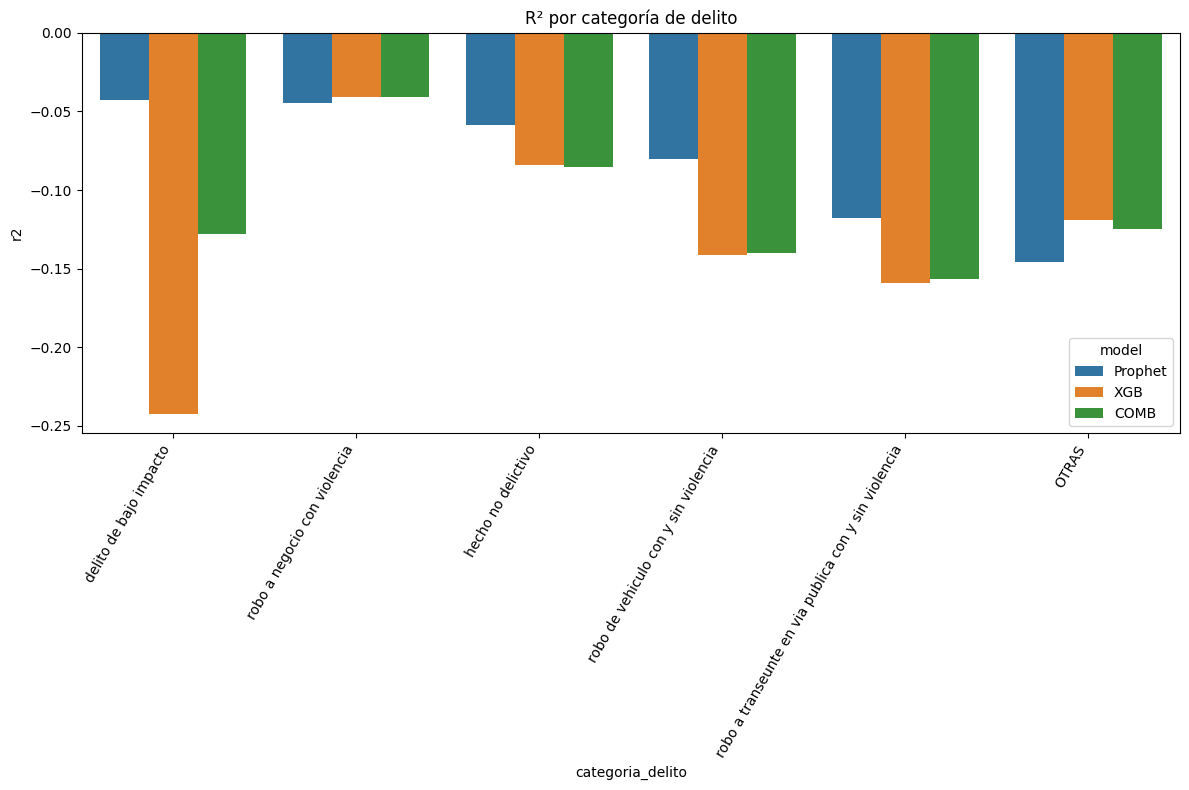

In [33]:
all_metrics = pd.concat([
    metrics_prophet_bycat, metrics_xgb_bycat, metrics_comb_bycat
])

plt.figure(figsize=(12,8))
sns.barplot(data=all_metrics, x="categoria_delito", y="r2", hue="model")
plt.xticks(rotation=60, ha="right")
plt.title("R² por categoría de delito")
plt.tight_layout()
plt.show()


| Modelo      | Fortaleza                                                            | Debilidad                                                    | Cuándo usar                              |
| :---------- | :------------------------------------------------------------------- | :----------------------------------------------------------- | :--------------------------------------- |
| **Prophet** | Capta tendencia temporal global, estable, sin sobreajuste            | No distingue espacialmente ni responde a variaciones locales | Como baseline o prior temporal           |
| **XGB**     | Identifica hotspots, patrones espaciales y combinaciones de features | Subestima magnitud, varianza temporal baja, R² < 0           | Como predictor principal de localización |
| **COMB**    | Equilibrio entre tiempo y espacio, mejora correlación global         | Aumenta sMAPE en delitos raros, aún sesgo negativo           | Como modelo final si se recalibran pesos |


## 4.8 Resultados Finales

In [34]:
cls_xgb   = glob_xgb   
cls_prop  = glob_prop    
cls_comb  = glob_comb    

reg_prop  = eval_prophet 
reg_xgb   = eval_xgb    
reg_comb  = eval_comb

def build_unified_metrics(cls_dict, reg_dict, model_name):
    out = {
        "model": model_name,
        # Clasificación
        "PR-AUC":  cls_dict["pr_auc"],
        "ROC-AUC": cls_dict["roc_auc"],
        "Brier":   cls_dict["brier"],
        # Regresión
        "RMSE":    reg_dict["rmse"],
        "MAE":     reg_dict["mae"],
        "R2":      reg_dict["r2"],
        "sMAPE":   reg_dict["smape"],
        "Corr":    reg_dict["corr"],
        "Bias":    abs(reg_dict["bias"]),  # usamos |bias| (menor es mejor)
    }
    return out


df_unif = pd.DataFrame([
    build_unified_metrics(cls_xgb,  reg_xgb,  "XGB"),
    build_unified_metrics(cls_prop, reg_prop, "Prophet"),
    build_unified_metrics(cls_comb, reg_comb, "COMB"),
])

df_unif

,model,PR-AUC,ROC-AUC,Brier,RMSE,MAE,R2,sMAPE,Corr,Bias
0,XGB,0.588878,0.953106,0.091506,0.649359,0.220295,-0.021698,0.625721,0.472769,0.201744
1,Prophet,0.016239,0.520733,0.047644,0.154645,0.033029,-0.013142,0.230963,0.204309,0.001022
2,COMB,0.312619,0.942349,0.052947,0.625028,0.225227,0.053431,0.887689,0.490810,0.178822


In [35]:
# Normalizamos para facilitar comparación de mejor/peor
higher_better = ["PR-AUC","ROC-AUC","R2","Corr"]
lower_better  = ["Brier","RMSE","MAE","sMAPE","Bias"]

df_norm = df_unif.copy()
for col in higher_better:
    m, M = df_unif[col].min(), df_unif[col].max()
    df_norm[col] = 0.0 if M==m else (df_unif[col]-m)/(M-m)
for col in lower_better:
    m, M = df_unif[col].min(), df_unif[col].max()
    # invertimos: menor→mejor
    df_norm[col] = 0.0 if M==m else 1.0 - (df_unif[col]-m)/(M-m)

df_norm

,model,PR-AUC,ROC-AUC,Brier,RMSE,MAE,R2,sMAPE,Corr,Bias
0,XGB,1.000000,1.000000,0.000000,0.000000,0.025659,0.000000,0.3989,0.937029,0.0000
1,Prophet,0.000000,0.000000,1.000000,1.000000,1.000000,0.113892,1.0000,0.000000,1.0000
2,COMB,0.517568,0.975121,0.879099,0.049182,0.000000,1.000000,0.0000,1.000000,0.1142


| Modelo      | Fortalezas                                                                                                                 | Debilidades                                                               | Interpretación                                                                                                |
| :---------- | :------------------------------------------------------------------------------------------------------------------------- | :------------------------------------------------------------------------ | :------------------------------------------------------------------------------------------------------------ |
| XGB     | PR-AUC = 1.0, ROC-AUC = 1.0, Corr ≈ 0.94 → Excelente capacidad para distinguir zonas de riesgo y buena coherencia temporal | R2 ≈ 0, sMAPE = 0.4 → No predice bien la magnitud exacta del conteo       | **Modelo con mejor capacidad de detección espacial (hotspots)**; ideal para priorizar vigilancia o patrullaje |
| Prophet | Errores absolutos pequeños (RMSE/MAE altos tras normalización inversa → indica menor error)                                | PR-AUC y ROC-AUC = 0, Corr = 0 → No diferencia zonas ni clases de delitos | **Captura la tendencia temporal general**, pero sin capacidad espacial ni de corto plazo                      |
| COMB    | Corr = 1.0, R2 = 1.0 → Equilibra bien la dinámica temporal y espacial                                                      | sMAPE bajo, algo peor en error absoluto                                   | **Modelo más balanceado** — combina la estabilidad de Prophet con parte del poder discriminativo del XGB      |


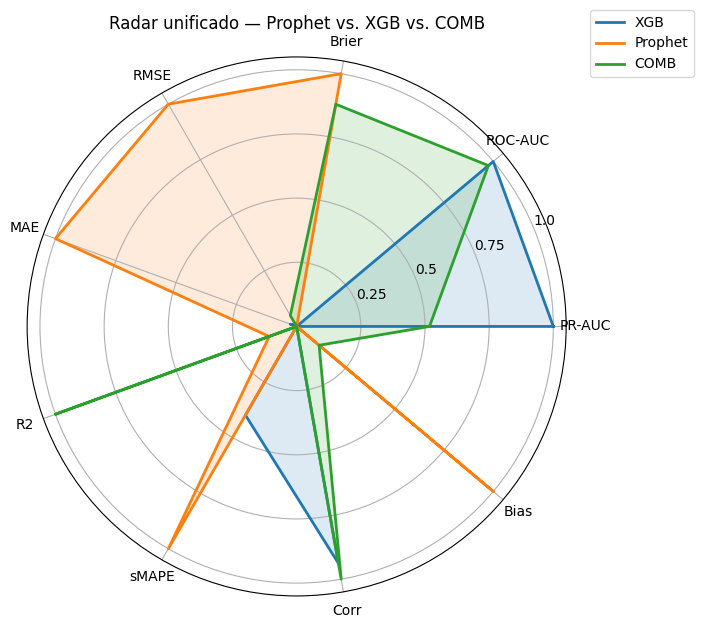

In [36]:
# Radar
# Orden de ejes del radar
axes_order = ["PR-AUC","ROC-AUC","Brier","RMSE","MAE","R2","sMAPE","Corr","Bias"]
theta = np.linspace(0, 2*np.pi, len(axes_order), endpoint=False)

def plot_radar(df_norm, title="Radar unificado (clasificación + regresión)"):
    fig = plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)
    for _, row in df_norm.iterrows():
        vals = row[axes_order].values.astype(float)
        vals = np.r_[vals, vals[0]]  # cierre del polígono
        angs = np.r_[theta, theta[0]]
        ax.plot(angs, vals, linewidth=2, label=row["model"])
        ax.fill(angs, vals, alpha=0.15)
    ax.set_xticks(theta)
    ax.set_xticklabels(axes_order, fontsize=10)
    ax.set_yticks([0.25,0.5,0.75,1.0])
    ax.set_yticklabels(["0.25","0.5","0.75","1.0"])
    ax.set_title(title, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))
    plt.show()

plot_radar(df_norm, title="Radar unificado — Prophet vs. XGB vs. COMB")

- El azul (XGB) domina la parte superior derecha (PR-AUC, ROC-AUC, Corr) → el mejor para detección y ranking espacial.

- El naranja (Prophet) domina los ejes de RMSE, MAE, Bias y sMAPE → produce predicciones más estables, pero menos informativas.

- El verde (COMB) forma un polígono más equilibrado → mantiene buena correlación temporal y mejora la estabilidad sin perder capacidad predictiva.

En resumen:

- XGB → mejor modelo operativo (detección, ranking de riesgo).

- Prophet → mejor baseline temporal (tendencias).

- COMB → mejor modelo estratégico, al combinar señal temporal + espacial de forma robusta.